In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

In [3]:
#loading the FASHION-MNIST Dataset
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
print("Number of training images", x_train.shape[0])

Number of training images 60000


In [5]:
print("Number of testing imgages", x_test.shape[0]) #10000 images for testing purpose

Number of testing imgages 10000


In [6]:
print("Image dimensions", x_train.shape[1:])

Image dimensions (28, 28)


In [7]:
#Nomalize the image pixel values between 0-1
x_train_norm=x_train.astype('float32')/255.0 #all the 60k images are getting normalized
x_test_norm=x_test.astype('float32')/255.0 #all the 10k images are getting normalized

In [8]:
x_train_norm

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [9]:
x_train_norm.min()

np.float32(0.0)

In [10]:
x_train_norm.max()

np.float32(1.0)

In [17]:
#Reshape the images to make them compatible with CNN layers
x_train_norm=x_train_norm.reshape(x_train_norm.shape[0],28,28,1)
x_test_norm=x_test_norm.reshape(x_test_norm.shape[0],28,28,1)

In [18]:
x_train_norm.shape

(60000, 28, 28, 1)

In [19]:
x_test_norm.shape

(10000, 28, 28, 1)

In [20]:
Class_labels={0:"T-shirt/top", 1:"Trouser", 2:"Pullover", 3:"Dress", 4:"Coat",
              5:"Sandal", 6:"Shirt", 7:"Sneaker", 8:"Bag", 9:"Ankle Boot"}

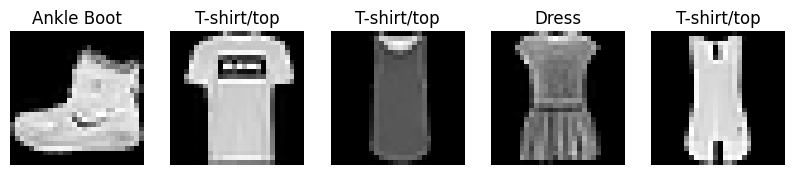

In [21]:
#Display five sample images alog with their class labels
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(x_train[i],cmap='gray')
  plt.title(Class_labels[y_train[i]])
  plt.axis('off')

In [22]:
#Building the CNN Image Classifier
model=models.Sequential([
    layers.Input(shape=(28,28,1),
                 name="input_layer"),
    layers.Conv2D(filters=16,activation='relu',kernel_size=(3,3),
                  name="conv_layer_1"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_1"),#[1,13,13,16]
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',
                  name="conv_layer_2"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_2"),#[1,5,5,32]
    layers.Flatten(name="flatten_layer"), #5x5x32 = 800 values
    layers.Dense(64,activation='relu',name="hidden_layer_1"),
    layers.Dense(32,activation='relu',name="hidden_layer_2"),
    layers.Dense(units=10,activation='softmax',name="output_layer")
])

In [23]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [73]:
#Train the CNN classifier and store the training history
history=model.fit(x_train_norm,y_train,epochs=10,batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9846 - loss: 0.0426
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9850 - loss: 0.0408
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9852 - loss: 0.0399
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9847 - loss: 0.0418
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9867 - loss: 0.0367
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9858 - loss: 0.0396
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9865 - loss: 0.0365
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9860 - loss: 0.0385
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9877 - loss: 0.0350
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9872 - loss: 0.0350


In [74]:
history.history.items()

dict_items([('accuracy', [0.9845666885375977, 0.9849666953086853, 0.9851666688919067, 0.9846833348274231, 0.9867333173751831, 0.9857500195503235, 0.9864833354949951, 0.9859833121299744, 0.987666666507721, 0.9872000217437744]), ('loss', [0.042590223252773285, 0.04079405963420868, 0.03992645815014839, 0.04179989919066429, 0.036738764494657516, 0.03962128236889839, 0.036470480263233185, 0.03851074352860451, 0.035044170916080475, 0.03503412753343582])])

In [79]:
print("Final Training Accuracy", round(history.history['accuracy'][-1]*100, 2), "%")

Final Training Accuracy 98.72 %


In [80]:
#Evaluate the model on the testing dataset
test_loss,test_accuracy=model.evaluate(x_test_norm,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8982 - loss: 0.7437


In [81]:
test_loss

0.7436985969543457

In [82]:
test_accuracy

0.8981999754905701

In [83]:
#Generate predictions for test images
predictions=model.predict(x_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [84]:
predictions.shape

(10000, 10)

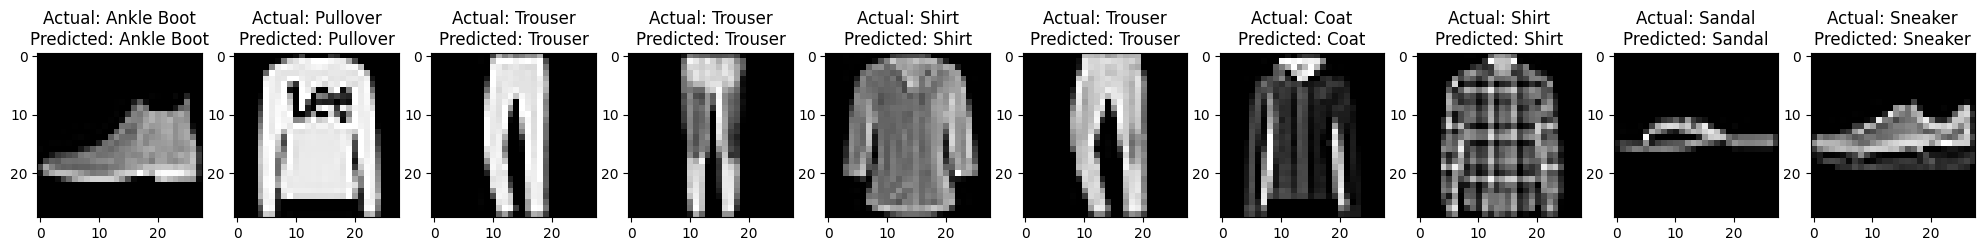

In [85]:
#Display predicted class labels for 10 test images
plt.figure(figsize=(25,5))
for i in range(10):
  plt.subplot(1,10,i+1)
  plt.imshow(x_test[i],cmap='gray')
  plt.title("Actual: "+Class_labels[y_test[i]]+"\nPredicted: "+Class_labels[np.argmax(predictions[i])])

In [86]:
#Evaluate the model
print("Test accuracy", round(test_accuracy*100, 2), "%")

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
y_pred=np.argmax(predictions,axis=1)
cm=confusion_matrix(y_test,y_pred)
print("\nConfusion matrix\n", cm)

report = classification_report(y_test, y_pred, target_names=list(Class_labels.values()))
print("\nClassification report\n", report)

Test accuracy 89.82 %

Confusion matrix
 [[788   0  22  16   5   1 160   0   7   1]
 [  4 974   0  13   4   0   2   0   3   0]
 [ 14   0 812  12  64   0  93   0   5   0]
 [ 12   2  10 890  38   0  40   1   7   0]
 [  2   0  45  22 857   0  71   0   3   0]
 [  3   0   0   0   0 977   0  13   1   6]
 [ 68   0  47  27  59   0 777   0  22   0]
 [  0   0   0   0   0   8   0 969   1  22]
 [  2   0   3   1   3   2   5   3 979   2]
 [  1   0   0   0   0   5   0  35   0 959]]

Classification report
               precision    recall  f1-score   support

 T-shirt/top       0.88      0.79      0.83      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.86      0.81      0.84      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.83      0.86      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.68      0.78      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag     

Model Analysis:


1. Why are CNNs more suitable than Artificial Neural Networks (ANNs) for image classification?

Ans: CNNs preserve spatial pixel relashionships, share weights to use fewer parameters, and automatically learn hierarchical features like edges and shapes instead of treating every pixel as an isolated output. ANNs require flattening 2D images into 1D vectors, which destroys neighbor-to-neighbor pixel content.


2. What is the purpose of a Convolution layer?

Ans: A convolution layer applies filters to an image to detect important features such as edges, patterns and shapes. These features help the network recognize and classify objects.


3. Why is Max Pooling used in CNNs?

Ans: Max pooling reduces the size of feature maps while retaining the most important information. It decreases computation time and helps in preventing overfitting.


4. Why is the Flatten layer required before the Dense layers?

Ans: The flatten layer converts multidimensional feature maps into a one dimentional vector. This allows Dense layers to process the extracted features for classification.


5. Why is the Softmax activation function used in the output layer?

Ans: The Softmax activation function turns raw, unscaled netwrok scores into a valid probability distribution. It forces every output value to fall between 0 and 1, and makes all output values add up to exactly 1. The class with the highest probability is chosen as the final prediction.
This makes it ideal for multi-class classification tasks.


6. How does the Adam optimizer help in training the CNN?

Ans: Adam automatically adjusts learning rates during training and updates weights efficiently. This helps model coverage faster and achieve better accuracy.